# IEOR 165 Final Project

# 1. Project Introduction

In this project, we aim to predict house selling prices by analyzing and modeling data. We will focus on how factors such as house area, number of bedrooms, number of bathrooms, etc., affect house prices.

# 2. Data Loading and Preliminary Exploration

First, we load the data and perform preliminary data exploration, including viewing basic information and statistical summaries. This step helps us to initially understand the structure and characteristics of the dataset.

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import statsmodels.api as sm
import matplotlib.pyplot as plt

In [ ]:
url='https://drive.google.com/file/d/1Tj2M5yj0SXZTTsFvN6243J-08WEKxBNb/view?usp=sharing'
url='https://drive.google.com/uc?id=' + url.split('/')[-2]
data = pd.read_csv(url)

In [ ]:
print("Data description:\n", data.describe())

Data description:
               price          area    bedrooms   bathrooms     stories  \
count  5.450000e+02    545.000000  545.000000  545.000000  545.000000   
mean   4.766729e+06   5150.541284    2.965138    1.286239    1.805505   
std    1.870440e+06   2170.141023    0.738064    0.502470    0.867492   
min    1.750000e+06   1650.000000    1.000000    1.000000    1.000000   
25%    3.430000e+06   3600.000000    2.000000    1.000000    1.000000   
50%    4.340000e+06   4600.000000    3.000000    1.000000    2.000000   
75%    5.740000e+06   6360.000000    3.000000    2.000000    2.000000   
max    1.330000e+07  16200.000000    6.000000    4.000000    4.000000   

          parking  
count  545.000000  
mean     0.693578  
std      0.861586  
min      0.000000  
25%      0.000000  
50%      0.000000  
75%      1.000000  
max      3.000000  


# 3. Data Cleaning

In [ ]:
print("Data info:\n")
data.info()

Data info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [ ]:
print("Missing values:\n", data.isnull().sum())

Missing values:
 price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


Since there are no missing values in your dataset, as indicated by your output, this step is not necessary. However, it's good to have a general approach ready in case you encounter missing data in the future.

# 4. Data Visualization

Using visualization tools, we analyzed the relationships between key variables such as house area and bedroom count, and price. These visualizations help us understand how different features potentially impact prices.

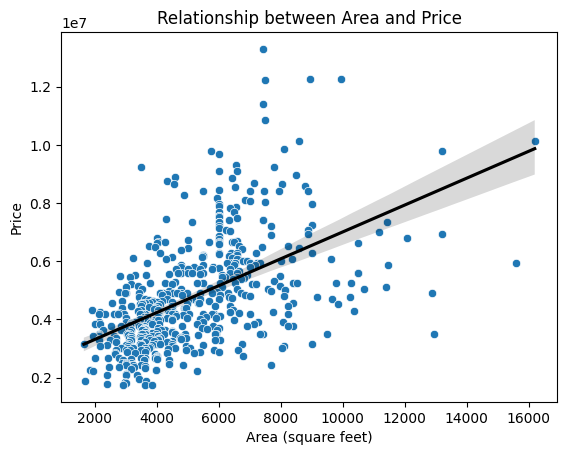

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(x='area', y='price', data=data)
sns.regplot(x='area', y='price', data=data, scatter=False, color='black')
plt.title('Relationship between Area and Price')
plt.xlabel('Area (square feet)')
plt.ylabel('Price')
plt.show()

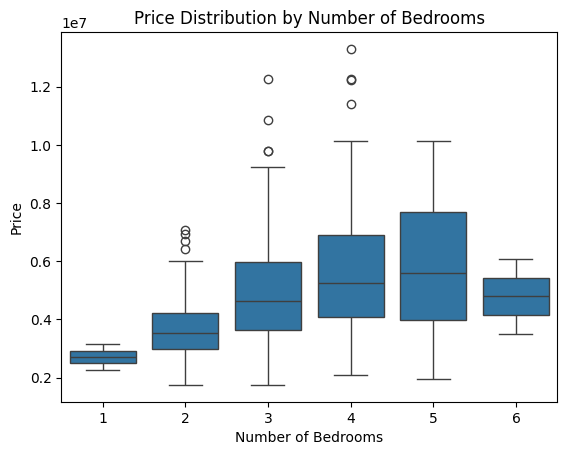

In [ ]:
sns.boxplot(x='bedrooms', y='price', data=data)
plt.title('Price Distribution by Number of Bedrooms')
plt.xlabel('Number of Bedrooms')
plt.ylabel('Price')
plt.show()

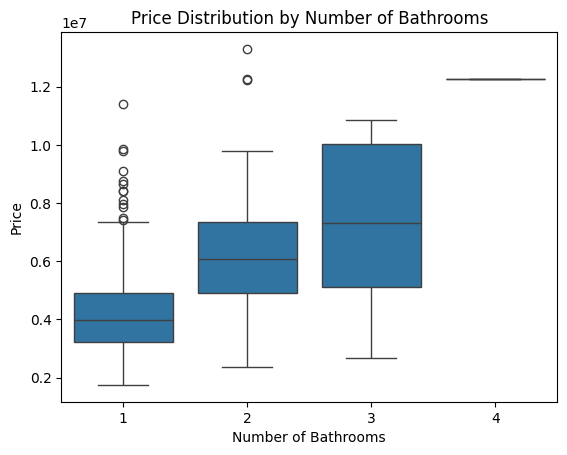

In [ ]:
sns.boxplot(x='bathrooms', y='price', data=data)
plt.title('Price Distribution by Number of Bathrooms')
plt.xlabel('Number of Bathrooms')
plt.ylabel('Price')
plt.show()

From the plotted charts, we observed the following relationships:

- Relationship Between Area and Price:
    The chart shows a clear positive correlation between house area and price. The larger the area, the generally higher the price. This indicates that area is an important predictive variable in model building.

- Relationship Between Number of Bedrooms and Price:
    As the number of bedrooms increases, the median price and range generally rise. However, this trend becomes less significant after more than 4 bedrooms, suggesting that other factors may begin to dominate.

- Relationship Between Number of Bathrooms and Price:
    There is also a positive correlation between the number of bathrooms and price. Particularly, the transition from 1 to 2 bathrooms significantly increases the median price. This variable should also be considered in the model.

# 5. Model Building and Evaluation

We used linear regression models as a baseline, and then tried ridge regression models to deal with potential multicollinearity issues. First, we need to prepare the data, convert categorical variables to numeric, and split the dataset into training and testing sets.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

categorical_features = ['mainroad', 'guestroom', 'basement', 'hotwaterheating',
                        'airconditioning', 'prefarea', 'furnishingstatus']

encoder = OneHotEncoder(drop='first', sparse=False)
encoded_features = encoder.fit_transform(data[categorical_features])

# Creating a DataFrame from the encoded features, adding appropriate column names
encoded_features_df = pd.DataFrame(encoded_features,
                                   columns=encoder.get_feature_names_out(categorical_features))

# Concatenate encoded features with the rest of the dataset (excluding original categorical columns)
housing_data_encoded = pd.concat([data.drop(categorical_features, axis=1), encoded_features_df], axis=1)

# Display the first few rows of the updated dataset
housing_data_encoded.head()

/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
1,12250000,8960,4,4,4,3,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,12250000,9960,3,2,2,2,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0
3,12215000,7500,4,2,2,3,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0
4,11410000,7420,4,1,2,2,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0


In [ ]:
X = housing_data_encoded.drop(columns=['price'])
y = housing_data_encoded['price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Model-1: Ordinary Least Squares

In [ ]:
X = sm.add_constant(housing_data_encoded.drop(columns=['price']))
y = housing_data_encoded['price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model_ols = sm.OLS(y_train, X_train)
results = model_ols.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.686
Model:                            OLS   Adj. R-squared:                  0.676
Method:                 Least Squares   F-statistic:                     70.90
Date:                Sat, 04 May 2024   Prob (F-statistic):           2.16e-97
Time:                        03:49:10   Log-Likelihood:                -6635.2
No. Observations:                 436   AIC:                         1.330e+04
Df Residuals:                     422   BIC:                         1.336e+04
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                                      coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
const     

In [ ]:
from sklearn.metrics import mean_squared_error
y_pred_ols = results.predict(X_test)
ols_mse = mean_squared_error(y_test, y_pred_ols, squared=True)
print("OLS MSE:", ols_mse)

OLS MSE: 1754318687330.6711


The function is f(x)=260000+235.97×area+76780×bedrooms+1094000×bathroom +407500×stories
+224800×parking+367900×mainroad_yes+231600×guestroom_yes
+390300×basement_yes+684600×hotwaterheating_yes
+791400×airconditioning_yes
+629900×prefarea_yes−126900×furnishingstatus_semi
-furnished−413600×furnishingstatus_unfurnished                          

Model-1: Ordinary Least Squares Evaluation Results:
- Mean Squared Error (MSE): 1754318687330.6711

## Model-2: Regularized Least Regression

### Ridge

In [ ]:
model_ridge = Ridge()
model_ridge.fit(X_train, y_train)
y_pred_ridge = model_ridge.predict(X_test)
ridge_mse = mean_squared_error(y_test, y_pred_ridge, squared=True)

### Cross Validation on Ridge

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

In [ ]:
grid_values = {'alpha': np.logspace(-2, 5, 120)}
model_ridge = Ridge()
model_ridge_cv = GridSearchCV(model_ridge, param_grid=grid_values,scoring='neg_mean_squared_error', cv=5)
model_ridge_cv.fit(X_train, y_train)
y_pred_ridge_cv = model_ridge_cv.best_estimator_.predict(X_test)
ridge_cv_mse = mean_squared_error(y_test, y_pred_ridge_cv, squared=True)

In [ ]:
print('Grid best parameter λ: ', model_ridge_cv.best_params_['alpha'])

Grid best parameter λ:  3.874675120456132


In [ ]:
ridge_cv_mse

1762969738938.3796

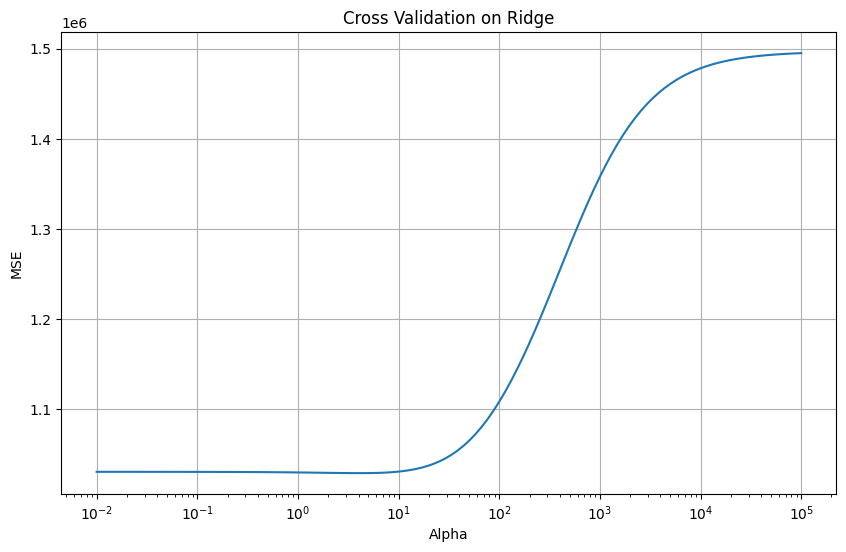

In [ ]:
rmse_scores = np.sqrt(-model_ridge_cv.cv_results_['mean_test_score'])
alpha_values = model_ridge_cv.param_grid['alpha']

plt.figure(figsize=(10, 6))
plt.plot(alpha_values, rmse_scores, linestyle='-')
plt.xscale('log')
plt.xlabel('Alpha')
plt.ylabel('MSE')
plt.title('Cross Validation on Ridge')
plt.grid(True)
plt.show()

In [ ]:
best_ridge_model = model_ridge_cv.best_estimator_
print("Best alpha value:", best_ridge_model.alpha)
print("Coefficients:", best_ridge_model.coef_)

Best alpha value: 3.874675120456132
Coefficients: [ 0.00000000e+00  2.40509795e+02  8.80913805e+04  1.04871055e+06
  4.14484766e+05  2.31167870e+05  3.48007024e+05  2.29924932e+05
  3.90694501e+05  5.67454603e+05  7.54969971e+05  5.98661110e+05
 -1.12603202e+05 -3.97423608e+05]


In [ ]:
print, best_ridge_model.intercept_

(<function print>, 274625.21718369797)

The function is:
f(x) = 274625.21718369797 + 240.5098×area + 88091.3805×bedrooms + 1048710.55×bathroom +
       414484.766×stories + 231167.87×parking + 348007.024×mainroad_yes + 229924.932×guestroom_yes +
       390694.501×basement_yes + 567454.603×hotwaterheating_yes + 754969.971×airconditioning_yes +
       598661.11×prefarea_yes - 112603.202×furnishingstatus_semi-furnished - 397423.608×furnishingstatus_unfurnished


Model-2: Regularized Least Regression Evaluation Results:
- Grid best parameter λ: 4.037017258596558
- Mean Squared Error (MSE): 1762969738938.3796

## Model-3: Nadaraya–Watson Kernel Regression

### Kernel Regression

In [ ]:
from sklearn.kernel_ridge import KernelRidge

In [ ]:
model_kernel = KernelRidge()
model_kernel.fit(X_train, y_train)
y_pred_kernel = model_kernel.predict(X_test)
kernel_mse = mean_squared_error(y_test, y_pred_kernel, squared=True)

### Cross Validation on Kernel Regression

In [ ]:
from statsmodels.nonparametric.kernel_regression import KernelReg
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

X_train_A = X_train[['area']]
X_test_A = X_test[['area']]
bw = np.linspace(0.05, 15, 150)

kernel_kr_rmse = []

for h in bw:
    kr = KernelReg(endog=y_train, exog=X_train_A, var_type='c', bw=[h])
    y_pred_cv, _ = kr.fit(X_train_A)
    mse = mean_squared_error(y_train, y_pred_cv)
    kernel_kr_rmse.append(mse)

optimal_bw = bw[np.argmin(kernel_kr_rmse)]

model_kernel_kr = KernelReg(endog=y_train, exog=X_train_A, var_type='c', bw=[optimal_bw])

In [ ]:
y_pred_test, _ = model_kernel_kr.fit(X_test_A)

test_mse = mean_squared_error(y_test, y_pred_test, squared=True)

In [ ]:
print(f"Grid best parameter h: {optimal_bw}")

Grid best parameter h: 0.05


In [ ]:
print(f"kernel_cv_mse: {test_mse}")

kernel_cv_mse: 12203023177333.334


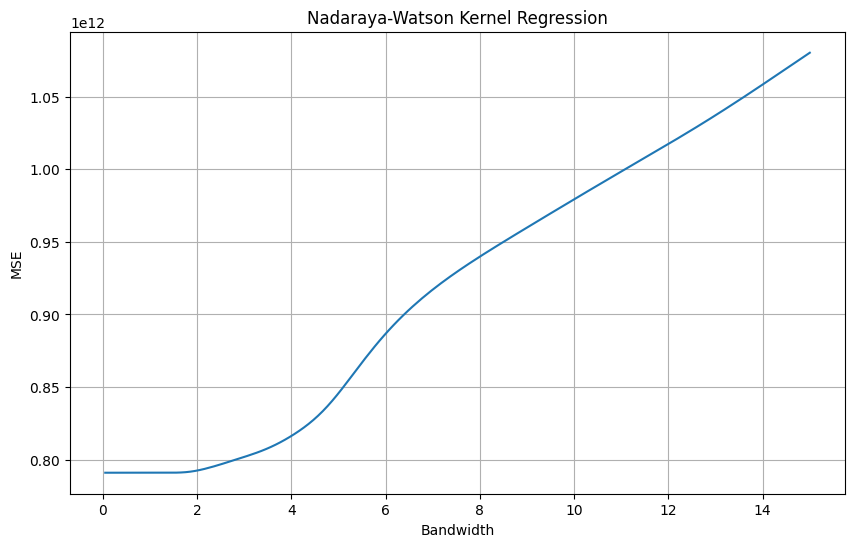

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(bw, kernel_kr_rmse)
plt.xlabel('Bandwidth')
plt.ylabel('MSE')
plt.title('Nadaraya-Watson Kernel Regression')
plt.grid(True)

Model-3: Nadaraya–Watson Kernel Regression Evaluation Results:
- Grid best parameter h:  0.05
- Mean Squared Error (MSE): 12203023177333.334

# 6. Results Analysis and Explanation

###Model 1: Ordinary Least Squares
- Root Mean Squared Error (MSE): 1754318687330.6711
-Function: f(x)=260000+235.97×area+76780×bedrooms+1094000×bathroom+
407500×stories+ 224800×parking+367900×mainroad_yes+
231600×guestroom_yes+ 390300×basement_yes+
684600×hotwaterheating_yes+ 791400×airconditioning_yes+
629900×prefarea_yes− 126900×furnishingstatus_semi-
furnished− 413600×furnishingstatus_unfurnished

###Model 2: Regularized Least Regression
- Grid best parameter λ: 4.037017258596558
-Mean Squared Error (MSE): 1762969738938.3796
-Function: f(x) = 240.5098×area + 88091.3805×bedrooms+ 1048710.55×bathroom+414484.766×stories + 231167.87×parking +348007.024×mainroad_yes+ 229924.932×guestroom_yes +390694.501×basement_yes+ 567454603×hotwaterheating_yes +754969.971×airconditioning_yes + 598661.11×prefarea_yes -112603.202×furnishingstatus_semi-furnished - 397423.608×furnishingstatus_unfurnished

###Model 3: Nadaraya–Watson Kernel Regression
- Grid best parameter h:  0.05

- Mean Squared Error (MSE): 12203023177333.334

- price=g(area)+  ε

##Comparison:
All three models have high MSE values, which represent prediction errors. However, the OLS and regularized models have similar MSE, which is significantly lower than the MSE of the Nadaraya-Watson kernel regression model in the latest results. This means that for this data set and under these conditions, the Nadaraya-Watson model performs poorly compared to the linear model.

###Three model explanation:
*   OLS: Provides simple explanations but may be susceptible to overfitting and multicollinearity. In this data report, the MSE is about 1754318687330.6711, which is a bit high but is the lowest among the three models.

*   Regularized Regression: Introduces a penalty term (Alpha), which helps reduce overfitting and manages multicollinearity better than OLS. Compared with OLS, the coefficients are slightly adjusted, which may produce a more robust model to prevent overfitting. The final RMSE is roughly the same is about 1762969738938.3796.

*   Nadaraya-Watson: This non-parametric approach is generally more flexible and can model non-linear relationships. However, the significantly higher MSE in this result set is approximately 12203023177333.334, which is relatively high compared to the other two models, indicating that it may be overfitting or misspecifying this particular data set.

##Best model:
Based on the results, Model 1 (OLS) appears to be the best model for this particular data set as it achieves the lowest RMSE. This shows that a simple linear approach is sufficient to capture the relationship between features and target variables without the need for regularization or the complexity of nonlinear modeling in the other two models. But although the OLS model provides the best fit based on MSE, the assumptions of linear regression are verified to ensure the validity of the OLS model. We consider further adjusting the regularization parameter model 2 because the two values ​​are similar. If we explore more deeply such as linearity, independence, homoscedasticity and residual normal distribution, we can find different results.


